# Notebook 2: Baseline Model
## IDS Feature Selection & Hyperparameter Optimization
### COMP2024 — AI Methods Coursework

This notebook loads the preprocessed data and establishes our baseline performance using a Random Forest classifier with all features and default hyperparameters. This gives us the target score we aim to beat during metaheuristic optimization.

In [1]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

plt.rcParams.update({'font.size': 11, 'figure.figsize': (10, 6)})
RANDOM_SEED = 42
RESULTS_DIR = 'results'

## 1. Load Preprocessed Data

In [2]:
with open(os.path.join(RESULTS_DIR, 'preprocessed_data.pkl'), 'rb') as f:
    data = pickle.load(f)

X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']
feature_names = data['feature_names']
print(f'Loaded cleaned data: Train={X_train.shape}, Test={X_test.shape}')

Loaded cleaned data: Train=(70000, 78), Test=(30000, 78)


## 2. Train Baseline Random Forest

In [3]:
start_time = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
runtime = time.time() - start_time

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fpr = fp / (fp + tn)

print(f"Baseline Accuracy: {acc:.4f}")
print(f"Baseline Precision: {prec:.4f}")
print(f"Baseline Recall: {rec:.4f}")
print(f"Baseline F1: {f1:.4f}")
print(f"Baseline FPR: {fpr:.4f}")
print(f"Runtime: {runtime:.2f}s")

Baseline Accuracy: 0.9975
Baseline Precision: 0.9966
Baseline Recall: 0.9883
Baseline F1: 0.9924
Baseline FPR: 0.0007
Runtime: 1.65s


## 3. Confusion Matrix & Feature Importance

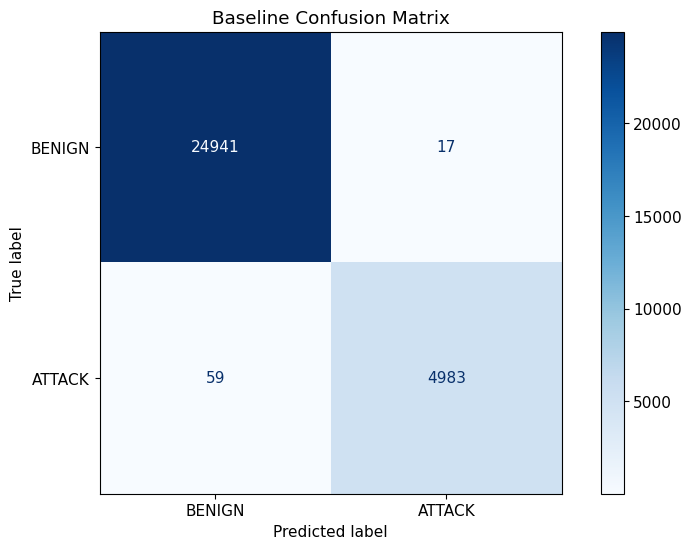

In [4]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['BENIGN', 'ATTACK'])
disp.plot(cmap='Blues')
plt.title('Baseline Confusion Matrix')
plt.savefig(os.path.join(RESULTS_DIR, 'baseline_confusion_matrix.png'))
plt.show()

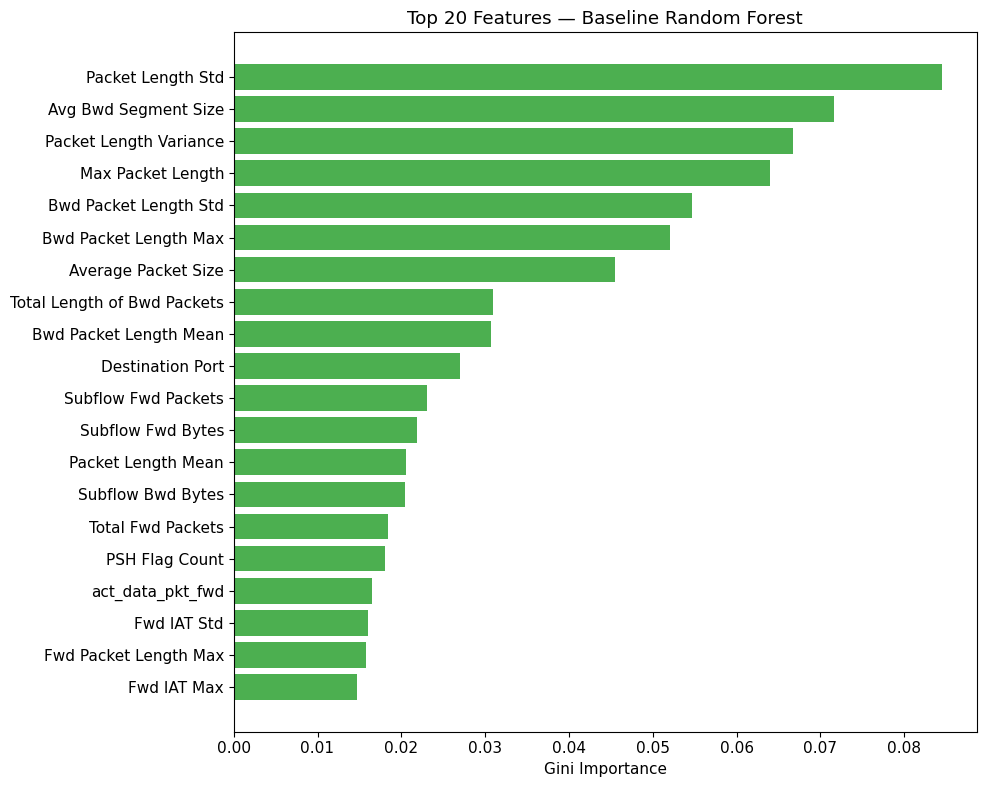

In [5]:
importances = rf.feature_importances_
df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False)
top20 = df_imp.head(20)

plt.figure(figsize=(10, 8))
plt.barh(range(len(top20)), top20['Importance'].values[::-1], color='#4CAF50')
plt.yticks(range(len(top20)), top20['Feature'].values[::-1])
plt.xlabel('Gini Importance')
plt.title('Top 20 Features — Baseline Random Forest')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'baseline_feature_importance.png'))
plt.show()

## 4. Save Baseline Results

In [6]:
baseline_results = {
    'algorithm': 'Baseline (Random Forest)',
    'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1, 'false_positive_rate': fpr,
    'num_features_selected': X_train.shape[1],
    'feature_ratio': 1.0,
    'hyperparams': {'n_estimators': 100, 'max_depth': None},
    'runtime_seconds': runtime,
}
with open(os.path.join(RESULTS_DIR, 'baseline_results.json'), 'w') as f:
    json.dump(baseline_results, f, indent=2)
print('✅ Baseline results saved! Proceed to Notebook 03_metaheuristics.ipynb.')

✅ Baseline results saved! Proceed to Notebook 03_metaheuristics.ipynb.
